# Convexity


1. definition
2. epigraph / sublevel set
3. supporting hyperplane
4. first-order inequality
5. Hessian / PSD matrix

In [26]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.patches import Circle
from scipy.spatial import ConvexHull
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(7)

mpl.rcParams["figure.figsize"] = (6, 4)
mpl.rcParams["font.size"] = 12
mpl.rcParams["axes.grid"] = True


In [27]:
def make_grid(xlim, ylim, n=300):
    x = np.linspace(xlim[0], xlim[1], n)
    y = np.linspace(ylim[0], ylim[1], n)
    return np.meshgrid(x, y)

def quadratic_form(A, X, Y):
    return A[0, 0] * X**2 + 2 * A[0, 1] * X * Y + A[1, 1] * Y**2

def plot_epigraph(ax, x, y, title, ylim=None):
    ax.plot(x, y, linewidth=2.5)
    if ylim is not None:
        ax.set_ylim(*ylim)
        upper = np.full_like(y, ylim[1])
    else:
        margin = 0.15 * (np.max(y) - np.min(y) + 1e-6)
        upper = np.full_like(y, np.max(y) + margin)
    ax.fill_between(x, y, upper, alpha=0.25)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("t")

def stable_logsumexp2(x, y):
    m = np.maximum(x, y)
    return m + np.log(np.exp(x - m) + np.exp(y - m))

def gradient_descent_quadratic(A, x0, step, num_steps):
    path = [x0.copy()]
    values = [x0 @ A @ x0]
    x = x0.copy()
    for _ in range(num_steps):
        grad = 2 * A @ x
        x = x - step * grad
        path.append(x.copy())
        values.append(x @ A @ x)
    return np.array(path), np.array(values)


## Part 0.Intro

볼록성은 최적화, 통계, 머신러닝, 제어, 신호처리 등에서 반복해서 등장합니다.  
이유는 간단합니다. **문제를 훨씬 덜 위험하게 만들기 때문**입니다.

- convex set은 “중간을 잃어버리지 않는” 집합입니다.
- convex function은 “직선을 이기는 방향으로 위로 휘는” 함수입니다.
- convex optimization에서는 local minimum이 global minimum이 됩니다.

이 파트에서 먼저 기억해야 할 최소 개념은 다음입니다.

### 1. Affine combination
두 점 $x,y$와 $\lambda \in [0,1]$에 대해
$\lambda x + (1-\lambda)y$ 를 두 점 사이의 affine combination이라 합니다.  
집합이 convex라는 말은 이 점이 항상 집합 안에 남는다는 뜻입니다.

### 2. Convex set
집합 $C$가 convex라는 것은
$x,y \in C,\ \lambda\in[0,1] \implies \lambda x + (1-\lambda)y \in C$
를 만족한다는 뜻입니다.

### 3. Convex function
함수 $f$가 convex라는 것은
$f(\lambda x + (1-\lambda)y) \le \lambda f(x) + (1-\lambda) f(y)$
를 만족한다는 뜻입니다.

### 4. Gradient와 Hessian
- gradient는 1차 변화율 정보
- Hessian은 2차 곡률 정보  
를 담고 있습니다.

> **-> 체크리스트**  
> 어떤 그림을 보든 “이건 정의, epigraph, sublevel set, first-order, Hessian 중 어떤 방식으로 설명할까?”를 항상 자문하세요.


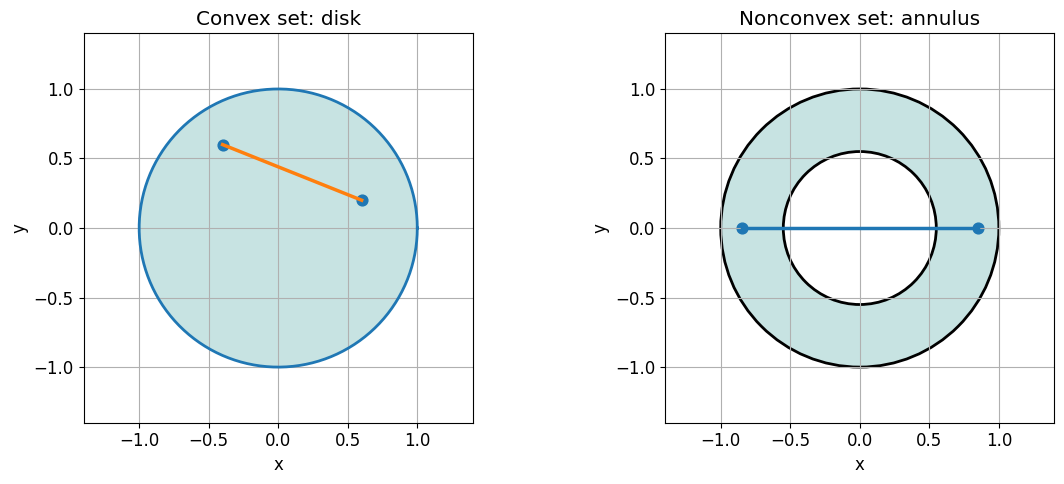

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Convex disk
ax = axes[0]
X, Y = make_grid((-1.4, 1.4), (-1.4, 1.4), n=400)
Z = X**2 + Y**2
ax.contourf(X, Y, Z, levels=[0, 1], alpha=0.25)
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), linewidth=2)
p = np.array([0.6, 0.2])
q = np.array([-0.4, 0.6])
segment = np.linspace(0, 1, 200)[:, None] * p + np.linspace(1, 0, 200)[:, None] * q
ax.plot(segment[:, 0], segment[:, 1], linewidth=2.5)
ax.scatter([p[0], q[0]], [p[1], q[1]], s=60)
ax.set_title("Convex set: disk")
ax.set_aspect("equal")
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_xlabel("x")
ax.set_ylabel("y")

# Nonconvex annulus
ax = axes[1]
R = np.sqrt(X**2 + Y**2)
ax.contourf(X, Y, ((R >= 0.55) & (R <= 1.0)).astype(float), levels=[0.5, 1.5], alpha=0.25)
ax.add_patch(Circle((0, 0), 1.0, fill=False, linewidth=2))
ax.add_patch(Circle((0, 0), 0.55, fill=False, linewidth=2))
p = np.array([0.85, 0.0])
q = np.array([-0.85, 0.0])
segment = np.linspace(0, 1, 200)[:, None] * p + np.linspace(1, 0, 200)[:, None] * q
ax.plot(segment[:, 0], segment[:, 1], linewidth=2.5)
ax.scatter([p[0], q[0]], [p[1], q[1]], s=60)
ax.set_title("Nonconvex set: annulus")
ax.set_aspect("equal")
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.tight_layout()
plt.show()


위 그림은  **line-segment test**를 가장 직접적으로 보여줍니다.

- 원판(disk)은 두 점을 잇는 선분이 항상 내부에 남습니다.
- 고리(annulus)는 양쪽 점은 집합 안에 있어도, 그 중간 선분이 가운데 구멍을 통과하므로 convex가 아닙니다.

### 수업에서 다룬 내용 -> recap
1. 왜 halfspace는 convex일까요?
2. 왜 두 개의 떨어진 disk의 합집합은 convex가 아닐까요?
3. 왜 simplex(예: 삼각형, 사면체)는 convex일까요?

### 짧은 해설
- halfspace는 선형 부등식 하나로 정의되므로 중간점도 같은 부등식을 만족합니다.
- 떨어진 두 disk의 합집합은 다른 disk에 있는 두 점의 중점이 바깥으로 나갈 수 있습니다.
- simplex는 꼭짓점의 convex combination 전체이므로 정의상 convex입니다.


## Part 1. Convex sets, convex hulls, supporting hyperplanes 

**집합의 convexity** 

### 1. 왜 ellipsoid가 convex인가?
타원체는 “둥글어서” convex한 것이 아니라,
$\{x : x^\top P x \le 1\}, \qquad P \succeq 0$

처럼 **convex quadratic function의 sublevel set**이기 때문에 convex합니다.

즉, 나중에 함수 convexity를 배우면 “타원체가 왜 convex인가?”도 같은 언어로 설명할 수 있습니다.

### 2. 왜 convex hull가 중요한가?
convex hull은 주어진 점들을 “모든 평균과 혼합”으로 채운 집합입니다.
$\operatorname{conv}\{p_1,\dots,p_k\}=
\left\{
\sum_{i=1}^k \lambda_i p_i :
\lambda_i \ge 0,\ \sum_i \lambda_i = 1
\right\}$

이는 데이터의 외곽선, feasible region의 다면체 근사, random sampling의 geometric summary 등에서 중요합니다.

### 3. supporting hyperplane은 무엇을 말해주는가?
convex set의 경계점에서는 집합 전체가 한쪽에 놓이도록 “받쳐주는” 직선/평면을 잡을 수 있습니다.  
이 아이디어는 나중에 convex function의 **tangent line / tangent plane underestimator**로 그대로 이어집니다.

> **핵심 연결고리**  
> convex function의 epigraph는 convex set이고, 그 epigraph를 받치는 hyperplane이 곧 first-order inequality의 기하학적 버전입니다.


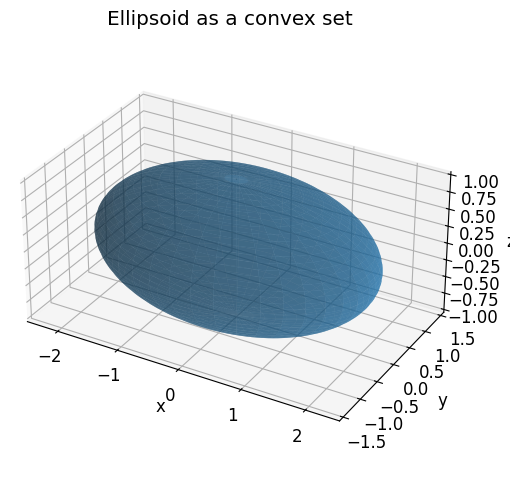

In [29]:
a, b, c = 2.2, 1.4, 1.0

u = np.linspace(0, 2 * np.pi, 120)
v = np.linspace(0, np.pi, 80)
U, V = np.meshgrid(u, v)

X = a * np.cos(U) * np.sin(V)
Y = b * np.sin(U) * np.sin(V)
Z = c * np.cos(V)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, alpha=0.55, linewidth=0.2)
ax.set_title("Ellipsoid as a convex set")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect((a, b, c))
plt.tight_layout()
plt.show()


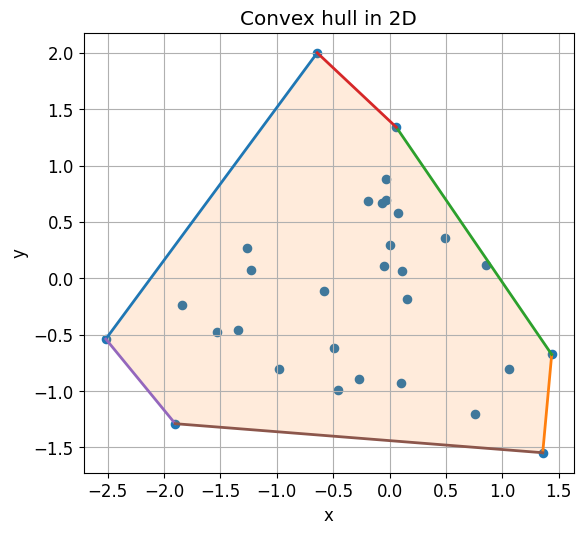

In [30]:
points = rng.normal(size=(30, 2))
hull = ConvexHull(points)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(points[:, 0], points[:, 1], s=35)
for simplex in hull.simplices:
    ax.plot(points[simplex, 0], points[simplex, 1], linewidth=2)
hull_pts = points[hull.vertices]
hull_pts = np.vstack([hull_pts, hull_pts[0]])
ax.fill(hull_pts[:, 0], hull_pts[:, 1], alpha=0.15)
ax.set_title("Convex hull in 2D")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


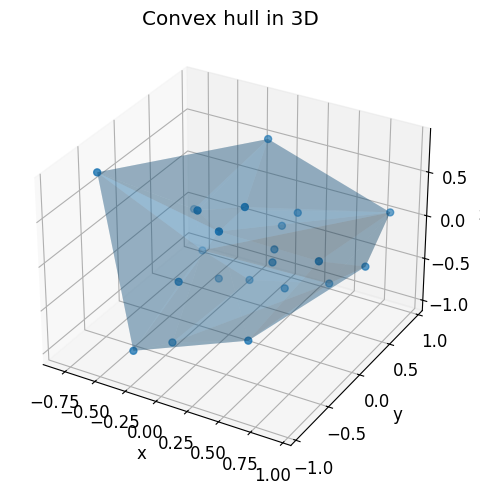

In [31]:
points3 = rng.uniform(-1, 1, size=(22, 3))
hull3 = ConvexHull(points3)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(points3[:, 0], points3[:, 1], points3[:, 2], s=25)
ax.plot_trisurf(
    points3[:, 0],
    points3[:, 1],
    points3[:, 2],
    triangles=hull3.simplices,
    alpha=0.25,
)
ax.set_title("Convex hull in 3D")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.tight_layout()
plt.show()


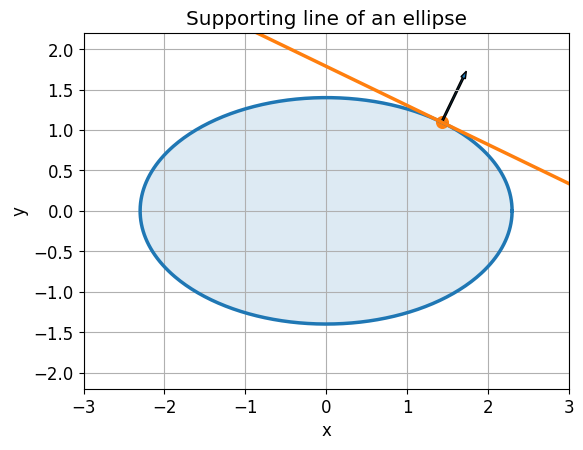

In [32]:
a, b = 2.3, 1.4
t0 = 0.9
x0 = a * np.cos(t0)
y0 = b * np.sin(t0)

theta = np.linspace(0, 2 * np.pi, 400)
x_ell = a * np.cos(theta)
y_ell = b * np.sin(theta)

x_line = np.linspace(-3, 3, 300)
y_line = (1 - x_line * x0 / a**2) * (b**2 / y0)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x_ell, y_ell, linewidth=2.5)
ax.fill(x_ell, y_ell, alpha=0.15)
ax.plot(x_line, y_line, linewidth=2.5)
ax.scatter([x0], [y0], s=70)
normal = np.array([x0 / a**2, y0 / b**2])
normal = normal / np.linalg.norm(normal)
ax.arrow(
    x0,
    y0,
    0.7 * normal[0],
    0.7 * normal[1],
    width=0.02,
    length_includes_head=True,
)
ax.set_title("Supporting line of an ellipse")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.set_xlim(-3, 3)
ax.set_ylim(-2.2, 2.2)
plt.tight_layout()
plt.show()


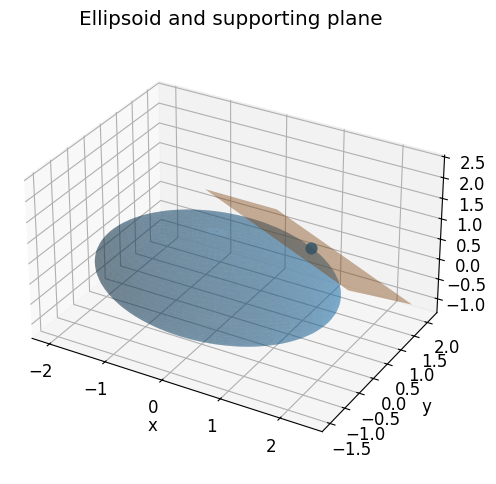

In [33]:
a, b, c = 2.0, 1.5, 1.1
u0, v0 = 0.8, 1.0
x0 = a * np.cos(u0) * np.sin(v0)
y0 = b * np.sin(u0) * np.sin(v0)
z0 = c * np.cos(v0)

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 80)
U, V = np.meshgrid(u, v)
X = a * np.cos(U) * np.sin(V)
Y = b * np.sin(U) * np.sin(V)
Z = c * np.cos(V)

xp = np.linspace(x0 - 1.2, x0 + 1.2, 40)
yp = np.linspace(y0 - 1.2, y0 + 1.2, 40)
XP, YP = np.meshgrid(xp, yp)
ZP = (1 - XP * x0 / a**2 - YP * y0 / b**2) * (c**2 / z0)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, alpha=0.35, linewidth=0.1)
ax.plot_surface(XP, YP, ZP, alpha=0.45)
ax.scatter([x0], [y0], [z0], s=60)
ax.set_title("Ellipsoid and supporting plane")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect((a, b, c))
plt.tight_layout()
plt.show()


### Part 1 정리와 체크 질문

1. 왜 타원체는 “보기에 둥글어서”가 아니라 **quadratic sublevel set**이라서 convex한가요?
2. 왜 convex hull는 선분 몇 개가 아니라 **내부 전체**를 채우나요?
3. supporting hyperplane은 왜 나중에 tangent line underestimator로 이어질까요?

### 짧은 해설
- ellipsoid는 $x^\top P x \le 1$ 꼴로 쓰이며, $P\succeq 0$이면 $x^\top P x$가 convex이므로 그 sublevel set은 convex입니다.
- convex hull는 모든 convex combination을 허용하므로, 꼭짓점 사이의 모서리뿐 아니라 내부 전체가 포함됩니다.
- 함수의 epigraph도 convex set이므로, 경계점에서의 supporting hyperplane을 함수 그래프로 다시 해석하면 접선/접평면의 global underestimator가 됩니다.


## Part 2. Convex functions, secant lines, epigraphs


### 1. secant line 관점
한 변수에서 convex function은 두 점을 이은 **secant line 아래에 그래프가 놓이는 함수**입니다.
$f(\lambda x + (1-\lambda)y) \le \lambda f(x) + (1-\lambda)f(y).$
즉, “함수값을 먼저 평균낸 것”이 “입력을 먼저 평균내고 함수값을 취한 것”보다 항상 크거나 같습니다.

### 2. epigraph 관점
함수의 epigraph는
$\operatorname{epi}(f)=\{(x,t): t\ge f(x)\}$
입니다.  
convex function이라는 말은 “그래프 위쪽 전체를 모은 집합이 convex set”이라는 말과 동치입니다.

이 관점이 중요한 이유는, 함수 문제를 다시 집합 문제로 바꿔주기 때문입니다.

### 3. domain이 왜 중요한가?
예를 들어 $-\log x$와 $x^{-3}$는 **$x>0$에서만** convex입니다.  
함수의 convexity는 그래프 모양만이 아니라 **정의역이 convex인지**도 함께 봐야 합니다.

### 4. smooth하지 않아도 convex일 수 있다
$|x|$, $|x|^{1.2}$ 같은 함수는 원점에서 매끈하지 않지만 convex입니다.  
따라서 “미분 가능 = convex의 필수 조건”은 아닙니다.

> **함수 판별 전략**  
> 각 예시를 볼 때 “가장 짧은 증명 도구”를 같이 생각하세요.  
> 어떤 함수는 second derivative가 가장 빠르고, 어떤 함수는 composition rule이 더 빠릅니다.


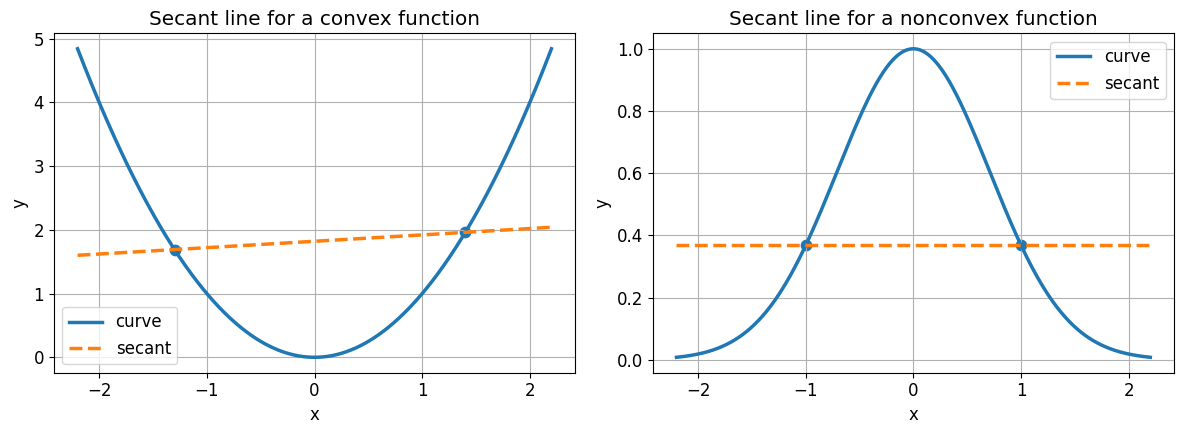

In [34]:
xs = np.linspace(-2.2, 2.2, 600)

f_convex = xs**2
x1, x2 = -1.3, 1.4
y1, y2 = x1**2, x2**2
secant_convex = y1 + (y2 - y1) * (xs - x1) / (x2 - x1)

f_nonconvex = np.exp(-xs**2)
x1b, x2b = -1.0, 1.0
y1b, y2b = np.exp(-x1b**2), np.exp(-x2b**2)
secant_nonconvex = y1b + (y2b - y1b) * (xs - x1b) / (x2b - x1b)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(xs, f_convex, linewidth=2.5, label="curve")
ax.plot(xs, secant_convex, "--", linewidth=2.5, label="secant")
ax.scatter([x1, x2], [y1, y2], s=55)
ax.set_title("Secant line for a convex function")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()

ax = axes[1]
ax.plot(xs, f_nonconvex, linewidth=2.5, label="curve")
ax.plot(xs, secant_nonconvex, "--", linewidth=2.5, label="secant")
ax.scatter([x1b, x2b], [y1b, y2b], s=55)
ax.set_title("Secant line for a nonconvex function")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()

plt.tight_layout()
plt.show()


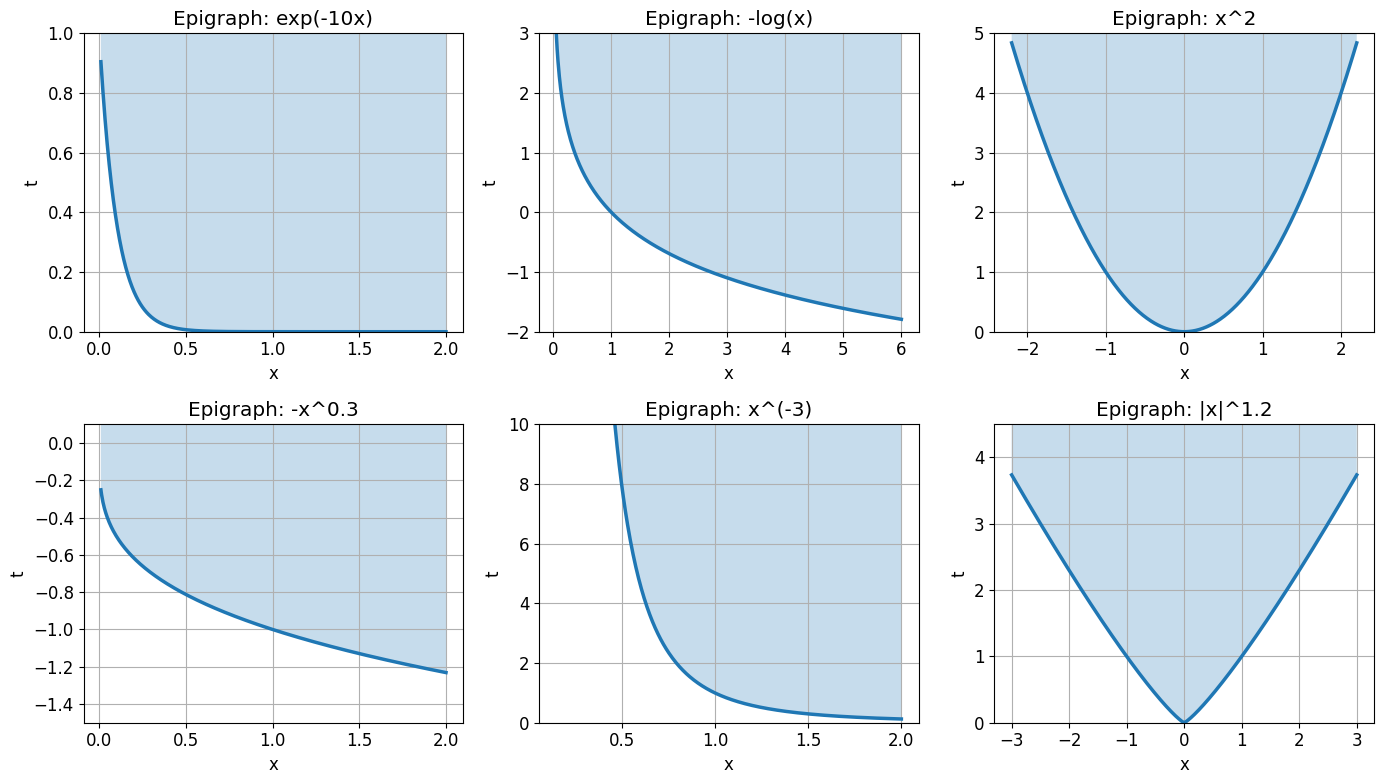

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

x = np.linspace(0.01, 2.0, 500)
plot_epigraph(axes[0, 0], x, np.exp(-10 * x), "Epigraph: exp(-10x)", ylim=(0, 1.0))

x = np.linspace(0.05, 6.0, 800)
plot_epigraph(axes[0, 1], x, -np.log(x), "Epigraph: -log(x)", ylim=(-2, 3))

x = np.linspace(-2.2, 2.2, 600)
plot_epigraph(axes[0, 2], x, x**2, "Epigraph: x^2", ylim=(0, 5))

x = np.linspace(0.01, 2.0, 500)
plot_epigraph(axes[1, 0], x, -x**0.3, "Epigraph: -x^0.3", ylim=(-1.5, 0.1))

x = np.linspace(0.15, 2.0, 500)
plot_epigraph(axes[1, 1], x, x**(-3), "Epigraph: x^(-3)", ylim=(0, 10))

x = np.linspace(-3.0, 3.0, 700)
plot_epigraph(axes[1, 2], x, np.abs(x)**1.2, "Epigraph: |x|^1.2", ylim=(0, 4.5))

plt.tight_layout()
plt.show()


### 예시별로 어떤 증명 도구가 자연스러운가?

| Function | Domain | 가장 자연스러운 설명 |
|---|---|---|
| $\exp(-10x)$ | $\mathbb{R}$ | exponential과 affine의 composition |
| $-\log x$ | $x>0$ | $f''(x)=1/x^2>0$ |
| $x^2$ | $\mathbb{R}$ | $f''(x)=2>0$ |
| $-x^{0.3}$ | $x>0$ | $x^{0.3}$는 concave, 음수를 붙이면 convex |
| $x^{-3}$ | $x>0$ | $f''(x)=12x^{-5}>0$ |
| $|x|^{1.2}$ | $\mathbb{R}$ | $p\ge 1$인 power / norm 관점, 원점에서 nonsmooth |

### 꼭 기억할 점
- epigraph가 convex이면 함수가 convex입니다.
- 그러나 **모양이 bowl처럼 보여도** 그 자체로 증명이 되지는 않습니다.
- 정의역이 convex가 아니면 함수 convexity를 논할 때 이미 문제가 생깁니다.

### 질문
1. 왜 $|x|$는 원점에서 미분 불가능하지만 convex일까요?
2. 왜 $-\log x$의 정의역을 $x>0$으로 제한해야 할까요?
3. $\exp(-x^2)$는 왜 convex가 아닐까요?

### 짧은 해설
- $|x|$는 삼각부등식과 secant-line geometry로 convex를 보일 수 있습니다.
- $-\log x$는 $x\le 0$에서 정의되지 않으므로 convex analysis의 표준 정의역은 $x>0$입니다.
- $\exp(-x^2)$는 가운데가 너무 높아서, 좌우 두 점을 잇는 secant line보다 그래프가 위로 튀어나옵니다.


## Part 3. Sublevel sets, contour plots

여기서는 수업시간에 크게 다루지는 않았지만, 실용적으로 contour plot을 더 정확하게 읽는 법을 다룹니다.

### 1. sublevel set이 핵심이다
convex function $f$에 대해
$S_\alpha = \{x : f(x)\le \alpha\}$
는 항상 convex입니다.  
즉, 2차원에서는 **곡면 전체보다 sublevel region을 보는 것이 더 직접적**일 때가 많습니다.

### 2. contour line과 filled sublevel region은 다르다
등고선 자체는
$\{x : f(x)=\alpha\}$
이고, 우리가 convexity에서 주로 쓰는 것은
$\{x : f(x)\le \alpha\}$
입니다.  

### 3. line restriction test
함수 $f:\mathbb{R}^n\to\mathbb{R}$가 convex라는 것은, 모든 직선
$t \mapsto x + td$
위로 제한한 1변수 함수
$g(t)=f(x+td)$
가 convex라는 것과 동치입니다.  
이 테스트는 반례를 잡을 때 특히 강력합니다.

### 4. 핵심 내용 (수업시간에 Log 관련된 문제는 직접해보라고했던 부분도 다시생각필요)
- `exp(-x^T A x)`는 **convex가 아니라 log-concave**
- `log(1 + x^2 + y^2)`는 **원점 근처만 볼록해 보일 뿐 전역 convex는 아님**

> **기억할 문장**  
> contour plot은 힌트일 뿐이고, convexity의 진짜 문장은 sublevel set / Hessian / line restriction이 말해줍니다.

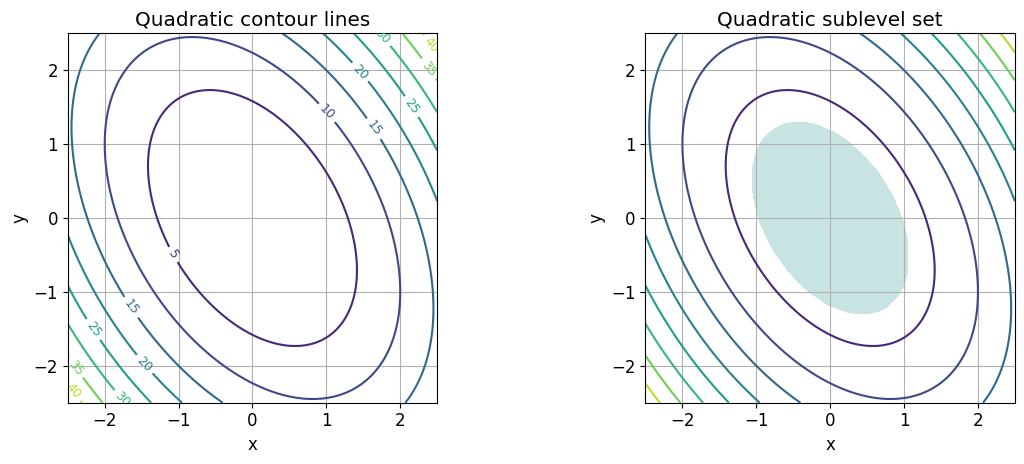

In [36]:
A = np.array([[3.0, 1.0], [1.0, 2.0]])
X, Y = make_grid((-2.5, 2.5), (-2.5, 2.5), n=400)
Z = quadratic_form(A, X, Y)
alpha = 2.8

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
cs = ax.contour(X, Y, Z, levels=8)
ax.clabel(cs, inline=True, fontsize=9)
ax.set_title("Quadratic contour lines")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")

ax = axes[1]
ax.contour(X, Y, Z, levels=8)
ax.contourf(X, Y, (Z <= alpha).astype(float), levels=[0.5, 1.5], alpha=0.25)
ax.set_title("Quadratic sublevel set")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()


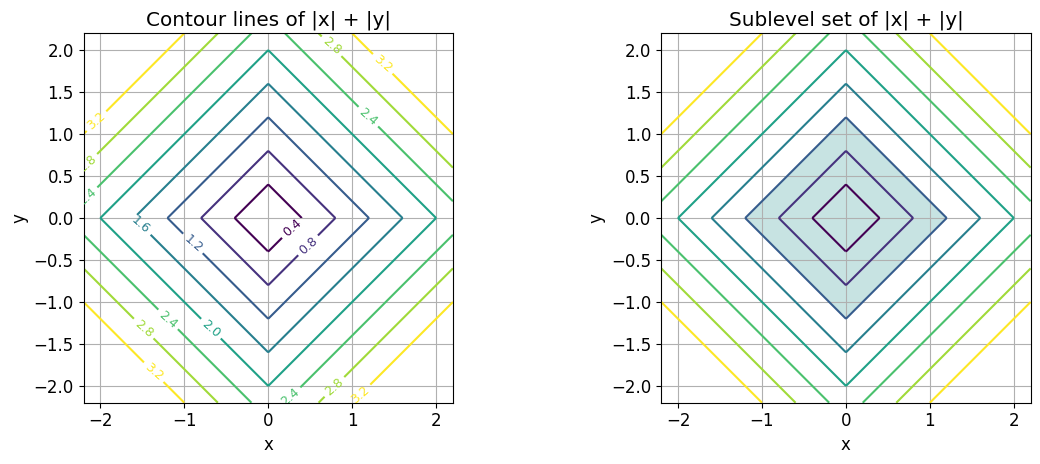

In [37]:
X, Y = make_grid((-2.2, 2.2), (-2.2, 2.2), n=400)
Z = np.abs(X) + np.abs(Y)
alpha = 1.2

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
cs = ax.contour(X, Y, Z, levels=np.linspace(0.4, 3.2, 8))
ax.clabel(cs, inline=True, fontsize=9)
ax.set_title("Contour lines of |x| + |y|")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")

ax = axes[1]
ax.contour(X, Y, Z, levels=np.linspace(0.4, 3.2, 8))
ax.contourf(X, Y, (Z <= alpha).astype(float), levels=[0.5, 1.5], alpha=0.25)
ax.set_title("Sublevel set of |x| + |y|")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()


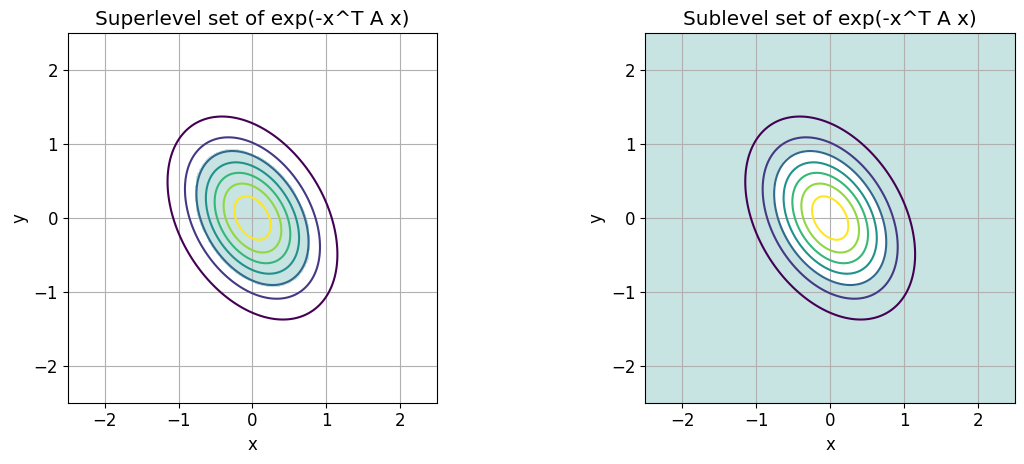

In [38]:
A = np.array([[2.0, 0.6], [0.6, 1.4]])
X, Y = make_grid((-2.5, 2.5), (-2.5, 2.5), n=400)
Q = quadratic_form(A, X, Y)
Z = np.exp(-Q)
alpha = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
ax.contour(X, Y, Z, levels=np.linspace(0.1, 0.9, 7))
ax.contourf(X, Y, (Z >= alpha).astype(float), levels=[0.5, 1.5], alpha=0.25)
ax.set_title("Superlevel set of exp(-x^T A x)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")

ax = axes[1]
ax.contour(X, Y, Z, levels=np.linspace(0.1, 0.9, 7))
ax.contourf(X, Y, (Z <= alpha).astype(float), levels=[0.5, 1.5], alpha=0.25)
ax.set_title("Sublevel set of exp(-x^T A x)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()


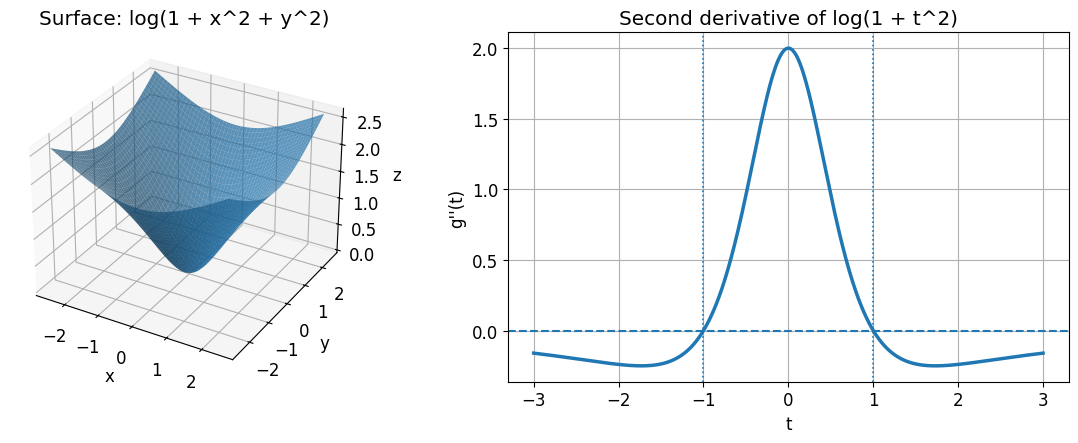

In [39]:
x = np.linspace(-2.5, 2.5, 400)
y = np.linspace(-2.5, 2.5, 400)
X, Y = np.meshgrid(x, y)
Z = np.log(1 + X**2 + Y**2)

t = np.linspace(-3.0, 3.0, 600)
gpp = 2 * (1 - t**2) / (1 + t**2)**2

fig = plt.figure(figsize=(12, 4.6))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(X, Y, Z, alpha=0.7, linewidth=0.1)
ax1.set_title("Surface: log(1 + x^2 + y^2)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

ax2 = fig.add_subplot(122)
ax2.plot(t, gpp, linewidth=2.5)
ax2.axhline(0, linestyle="--", linewidth=1.5)
ax2.axvline(-1, linestyle=":", linewidth=1.2)
ax2.axvline(1, linestyle=":", linewidth=1.2)
ax2.set_title("Second derivative of log(1 + t^2)")
ax2.set_xlabel("t")
ax2.set_ylabel("g''(t)")

plt.tight_layout()
plt.show()


### Part 3 질문 (이 부분도 수업시간에 다루진 않았지만 알아두면 좋은 내용)

1. 왜 $|x|+|y|$의 sublevel set은 다이아몬드 모양이면서도 convex일까요?
2. 왜 `exp(-x^T A x)`의 **superlevel set**은 convex지만, **sublevel set**은 일반적으로 convex가 아닐까요?
3. 왜 `log(1+x^2+y^2)`는 3D surface가 매끈해 보여도 전역 convex가 아닐까요?

### 짧은 해설
- $|x|+|y| \le \alpha$는 $\ell_1$ ball이므로 triangle inequality로 convex를 보일 수 있습니다.
- `exp(-x^T A x)`는 $x^\top A x$의 음의 지수형이므로 log-concave입니다. 따라서 superlevel set이 자연스럽게 convex합니다.
- `log(1+x^2+y^2)`를 $y=0$ 직선 위로 제한하면 $\log(1+t^2)$가 되고, 이 함수는 $|t|>1$에서 second derivative가 음수입니다.

> **체크 ㅊ포인트**  
> 원본 노트북의 contour 그림을 다시 볼 때는 반드시 “이게 sublevel인가, superlevel인가?”를 먼저 확인하세요.


## Part 4. First-order characterization, tangent underestimators, subgradients

이제 미분 가능한 convex function의 핵심 정리를 봅니다.

만약 $f$가 미분 가능하면, 다음은 서로 동치입니다.

$f \text{ is convex}
\quad \Longleftrightarrow \quad
f(y) \ge f(x) + \nabla f(x)^\top (y-x)
\quad \forall x,y.
$

오른쪽 식은 단순한 부등식이 아니라, 기하학적으로는 다음을 뜻합니다.

- 접선(tangent line)은 그래프를 **전역적으로 아래에서 받친다**
- 접평면(tangent plane)은 곡면을 **전역적으로 아래에서 받친다**

이 정리는 epigraph의 supporting hyperplane과 사실상 같은 내용입니다.

### nonsmooth한 경우는 어떻게 하나? (이 경우는 수업시간에 말로만 다루었으나, 아래 그래프를 통해 쉽게 이해가능)
$|x|$처럼 미분 불가능한 convex function도 많습니다.  
이때는 gradient 대신 **subgradient**를 사용합니다.

$g \in \partial f(x)
\quad \Longleftrightarrow \quad
f(y) \ge f(x) + g^\top (y-x)\ \ \forall y.
$

예를 들어
$
\partial |x|(0) = [-1,1]
$
입니다. 즉, 원점에서는 기울기 하나가 아니라 “허용되는 모든 접선 기울기”의 구간이 생깁니다.


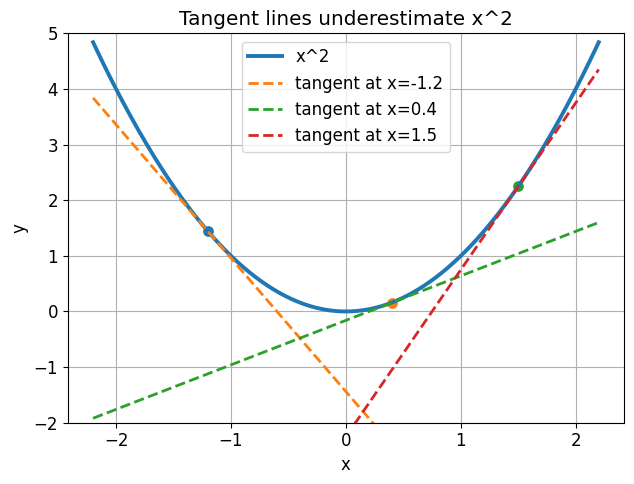

In [41]:
xs = np.linspace(-2.2, 2.2, 600)
ys = xs**2
x_points = [-1.2, 0.4, 1.5]

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(xs, ys, linewidth=2.8, label="x^2")

for x0 in x_points:
    y0 = x0**2
    slope = 2 * x0
    tangent = y0 + slope * (xs - x0)
    ax.plot(xs, tangent, "--", linewidth=2, label=f"tangent at x={x0}")
    ax.scatter([x0], [y0], s=45)

ax.set_title("Tangent lines underestimate x^2")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-2, 5)
ax.legend()
plt.tight_layout()
plt.show()


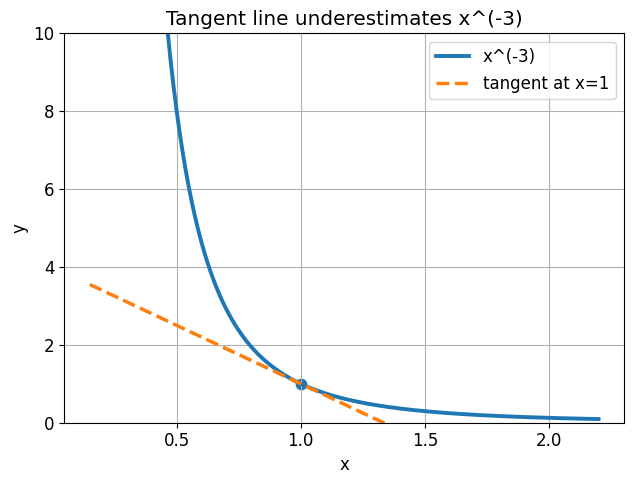

In [42]:
xs = np.linspace(0.15, 2.2, 500)
ys = xs**(-3)
x0 = 1.0
y0 = x0**(-3)
slope = -3 * x0**(-4)
tangent = y0 + slope * (xs - x0)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(xs, ys, linewidth=2.8, label="x^(-3)")
ax.plot(xs, tangent, "--", linewidth=2.5, label="tangent at x=1")
ax.scatter([x0], [y0], s=55)
ax.set_title("Tangent line underestimates x^(-3)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(0, 10)
ax.legend()
plt.tight_layout()
plt.show()


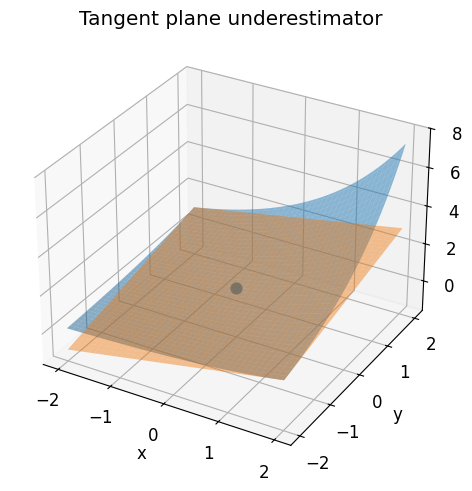

In [43]:
x = np.linspace(-2.0, 2.0, 80)
y = np.linspace(-2.0, 2.0, 80)
X, Y = np.meshgrid(x, y)

def f(X, Y):
    return np.exp(0.5 * X + 0.5 * Y)

Z = f(X, Y)

x0, y0 = 0.0, 0.0
z0 = f(x0, y0)
grad = np.array([0.5 * z0, 0.5 * z0])
TP = z0 + grad[0] * (X - x0) + grad[1] * (Y - y0)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, alpha=0.5, linewidth=0.1)
ax.plot_surface(X, Y, TP, alpha=0.45, linewidth=0.1)
ax.scatter([x0], [y0], [z0], s=60)
ax.set_title("Tangent plane underestimator")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.tight_layout()
plt.show()


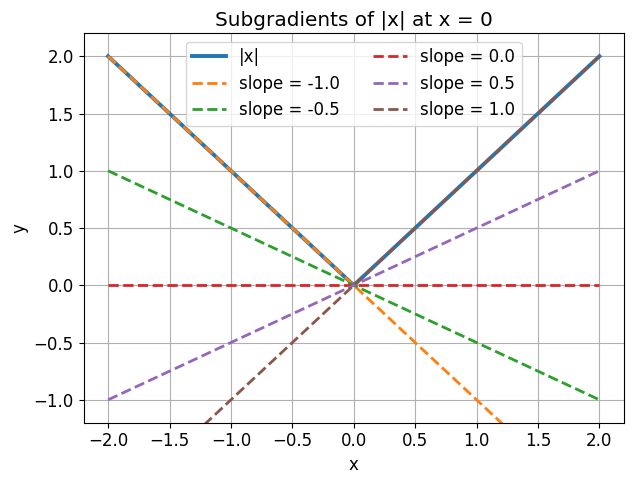

In [44]:
xs = np.linspace(-2.0, 2.0, 500)
ys = np.abs(xs)
slopes = [-1.0, -0.5, 0.0, 0.5, 1.0]

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(xs, ys, linewidth=2.8, label="|x|")

for g in slopes:
    line = g * xs
    ax.plot(xs, line, "--", linewidth=2, label=f"slope = {g}")

ax.set_title("Subgradients of |x| at x = 0")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-1.2, 2.2)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


### Part 4 생각해볼만한 질문

1. 왜 convex function의 접선은 “local approximation”을 넘어서 **global lower bound**가 되나요?
2. 왜 $|x|$는 gradient가 없는데도 subgradient는 많을까요?
3. 왜 epigraph의 supporting hyperplane과 first-order inequality는 같은 그림의 다른 표현일까요?

### 짧은 해설
- convexity 때문에 secant line 전체가 그래프 위에 있고, 그 극한으로 접선도 전역 하한이 됩니다.
- 원점에서 $|x|$는 뾰족하므로 기울기 하나는 없지만, $[-1,1]$의 모든 기울기가 아래에서 받치는 직선이 됩니다.
- epigraph의 경계에서 hyperplane이 한쪽으로 집합을 받친다는 말은, 함수 그래프에 대해 접선/접평면이 아래쪽에 놓인다는 말과 같습니다.


## Part 5. Hessian, PSD matrices, quadratics, quadratic-over-linear

미분 가능한 함수가 두 번 미분 가능할 때는 Hessian이 가장 빠른 도구가 되는 경우가 많습니다.

열린 convex domain에서 $f$가 $C^2$이면,

$\nabla^2 f(x) \succeq 0 \quad \forall x$

이면 $f$는 convex입니다.

### 1. 왜 PSD가 중요한가?
방향 $d$에 대한 곡률은

$d^\top \nabla^2 f(x)\, d$

로 측정됩니다.  
이 값이 모든 $d$에 대해 음수가 아니면, 모든 방향에서 아래로 꺼지는 방향이 없다는 뜻입니다.

### 2. quadratic function은 왜 중심 예시인가? (수업시간에 배운내용 상기)
$f(x)=x^\top A x + b^\top x + c$

의 Hessian은 $2A$입니다.  
따라서 convexity는 거의 전부 **행렬 \(A\)가 PSD인지 아닌지**로 결정됩니다.

### 3. quadratic-over-linear는 왜 중요한가?
$f(x,y)=\frac{x^2}{y}, \qquad y>0
$
는 convex optimization에서 자주 나오는 canonical example입니다.  
이 함수는 단순한 비율처럼 보이지만 사실은 **perspective transform**의 대표적 예시입니다.

$\frac{x^2}{y}=y\left(\frac{x}{y}\right)^2.$

### 4. strong convexity까지 보기
$A \succ 0$이면 quadratic은 단지 convex가 아니라 **strongly convex**입니다.  
이때 최적화 알고리즘은 더 안정적이고 빠르게 수렴하는 경향이 있습니다.


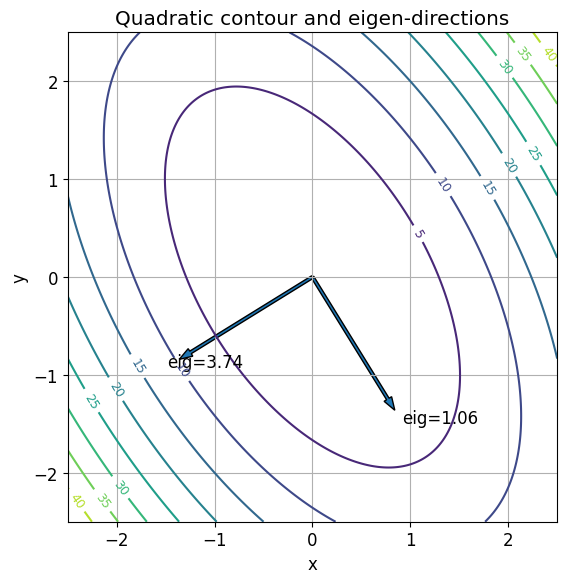

In [45]:
A = np.array([[3.0, 1.2], [1.2, 1.8]])
eigvals, eigvecs = np.linalg.eigh(A)

X, Y = make_grid((-2.5, 2.5), (-2.5, 2.5), n=300)
Z = quadratic_form(A, X, Y)

fig, ax = plt.subplots(figsize=(6, 6))
cs = ax.contour(X, Y, Z, levels=10)
ax.clabel(cs, inline=True, fontsize=9)

for i in range(2):
    v = eigvecs[:, i]
    lam = eigvals[i]
    ax.arrow(0, 0, 1.6 * v[0], 1.6 * v[1], width=0.03, length_includes_head=True)
    ax.text(1.75 * v[0], 1.75 * v[1], f"eig={lam:.2f}")

ax.set_title("Quadratic contour and eigen-directions")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


In [46]:
def hessian_log_one_plus_r2(x, y):
    r2 = x**2 + y**2
    factor1 = 2 / (1 + r2)
    factor2 = 4 / (1 + r2)**2
    H = factor1 * np.eye(2) - factor2 * np.array([[x**2, x*y], [x*y, y**2]])
    return H

Aq = np.array([[3.0, 1.2], [1.2, 1.8]])
H_quad = 2 * Aq
H_log_center = hessian_log_one_plus_r2(0.0, 0.0)
H_log_far = hessian_log_one_plus_r2(2.0, 0.0)
H_exp_neg_quad = -2 * np.array([[2.0, 0.6], [0.6, 1.4]])

rows = []
for name, point, H in [
    ("quadratic x^T A x", "(0, 0)", H_quad),
    ("log(1 + x^2 + y^2)", "(0, 0)", H_log_center),
    ("log(1 + x^2 + y^2)", "(2, 0)", H_log_far),
    ("exp(-x^T A x)", "(0, 0)", H_exp_neg_quad),
]:
    eigs = np.linalg.eigvalsh(H)
    if np.all(eigs > 1e-10):
        verdict = "positive definite / locally strongly convex"
    elif np.all(eigs >= -1e-10):
        verdict = "positive semidefinite / locally convex"
    elif np.all(eigs < -1e-10):
        verdict = "negative definite / locally concave"
    else:
        verdict = "indefinite / not convex at this point"
    rows.append(
        {
            "function": name,
            "point": point,
            "eigenvalues": np.round(eigs, 4).tolist(),
            "interpretation": verdict,
        }
    )

pd.DataFrame(rows)


,function,point,eigenvalues,interpretation
0,quadratic x^T A x,"(0, 0)","[2.1167, 7.4833]",positive definite / locally strongly convex
1,log(1 + x^2 + y^2),"(0, 0)","[2.0, 2.0]",positive definite / locally strongly convex
2,log(1 + x^2 + y^2),"(2, 0)","[-0.24, 0.4]",indefinite / not convex at this point
3,exp(-x^T A x),"(0, 0)","[-4.7416, -2.0584]",negative definite / locally concave


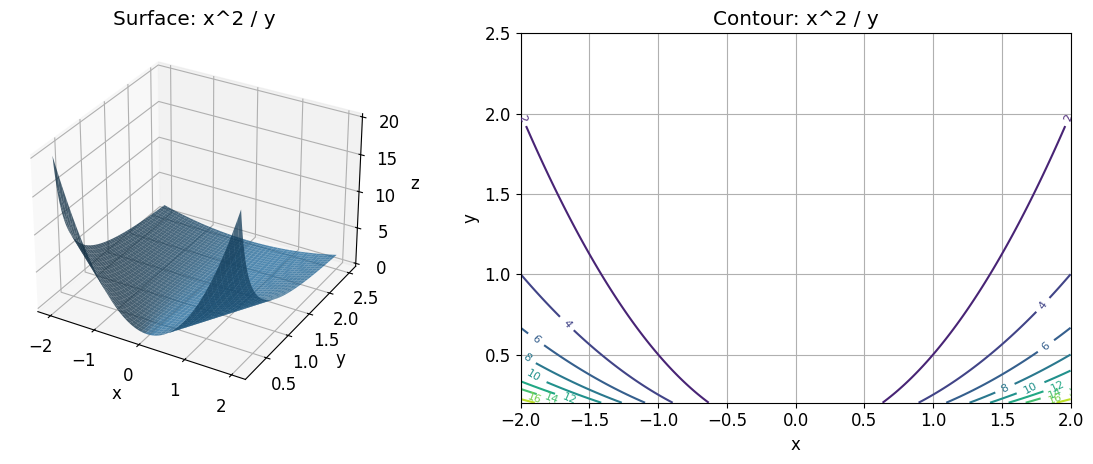

In [47]:
x = np.linspace(-2.0, 2.0, 180)
y = np.linspace(0.2, 2.5, 180)
X, Y = np.meshgrid(x, y)
Z = X**2 / Y

fig = plt.figure(figsize=(12, 4.8))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(X, Y, Z, alpha=0.75, linewidth=0.05)
ax1.set_title("Surface: x^2 / y")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

ax2 = fig.add_subplot(122)
cs = ax2.contour(X, Y, Z, levels=12)
ax2.clabel(cs, inline=True, fontsize=8)
ax2.set_title("Contour: x^2 / y")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

plt.tight_layout()
plt.show()


### Part 5 생각해볼만한 질문

1. 왜 quadratic function의 convexity는 행렬의 PSD 성질과 거의 같은 말인가요?
2. 왜 `log(1+x^2+y^2)`는 원점에서는 convex처럼 보이지만 멀리 가면 그렇지 않나요?
3. 왜 `x^2 / y`는 `y>0`라는 domain restriction이 필수인가요?

### 짧은 해설
- quadratic의 Hessian은 상수 행렬 $2A$이므로, convexity는 $A\succeq 0$인지에 의해 결정됩니다.
- `log(1+x^2+y^2)`의 Hessian은 위치에 따라 바뀌며, 멀리서는 음의 방향 곡률이 생깁니다.
- `x^2/y`는 $y\le 0$에서 표준 convex-analysis domain을 잃고, $y\to 0^+$에서 발산합니다. 따라서 자연스러운 convex domain은 $y>0$입니다.


## Part 6. Advanced examples: log-sum-exp, geometric mean, log-det 

### 1. log-sum-exp는 왜 중요한가? (수업시간에 꼭 풀어보라고 했던 내용)
$\operatorname{LSE}(x,y)=\log(e^x+e^y)$

는 convex이고, 동시에

$\max(x,y)\le \operatorname{LSE}(x,y)\le \max(x,y)+\log 2$

를 만족하는 **smooth maximum**입니다.  
머신러닝과 통계에서 softmax, partition function, variational bounds와 연결됩니다.

### 2. geometric mean은 왜 concave인가?
$
g(x,y)=\sqrt{xy}, \qquad x,y\ge 0
$
는 convex가 아니라 **concave**입니다.  
convex optimization에서는 convex 함수뿐 아니라, 이런 concave 함수를 최대화하는 문제도 매우 중요합니다.

### 3. log-det는 왜 핵심적인가?
positive definite matrix $X$에 대해
$
f(X)=\log\det(X)
$
는 concave입니다.  
이 함수는 semidefinite programming, covariance estimation, information geometry에서 자주 등장합니다.

> **Yoontae's Notice**  
> “좋은 함수”가 항상 convex인 것은 아닙니다.  
> optimization에서는 **convex minimization**과 **concave maximization**이 함께 자주 나타납니다.


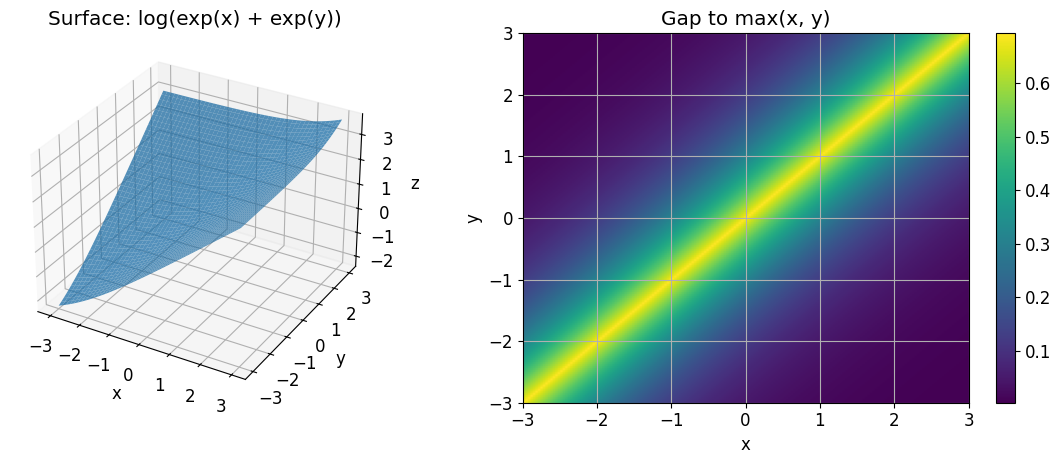

Maximum gap: 0.6931471805599454
log(2): 0.6931471805599453


In [48]:
x = np.linspace(-3, 3, 180)
y = np.linspace(-3, 3, 180)
X, Y = np.meshgrid(x, y)
Z = stable_logsumexp2(X, Y)
gap = Z - np.maximum(X, Y)

fig = plt.figure(figsize=(12, 4.8))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(X, Y, Z, alpha=0.75, linewidth=0.05)
ax1.set_title("Surface: log(exp(x) + exp(y))")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

ax2 = fig.add_subplot(122)
im = ax2.imshow(
    gap,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower",
    aspect="auto",
)
plt.colorbar(im, ax=ax2)
ax2.set_title("Gap to max(x, y)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

plt.tight_layout()
plt.show()

print("Maximum gap:", float(np.max(gap)))
print("log(2):", float(np.log(2)))


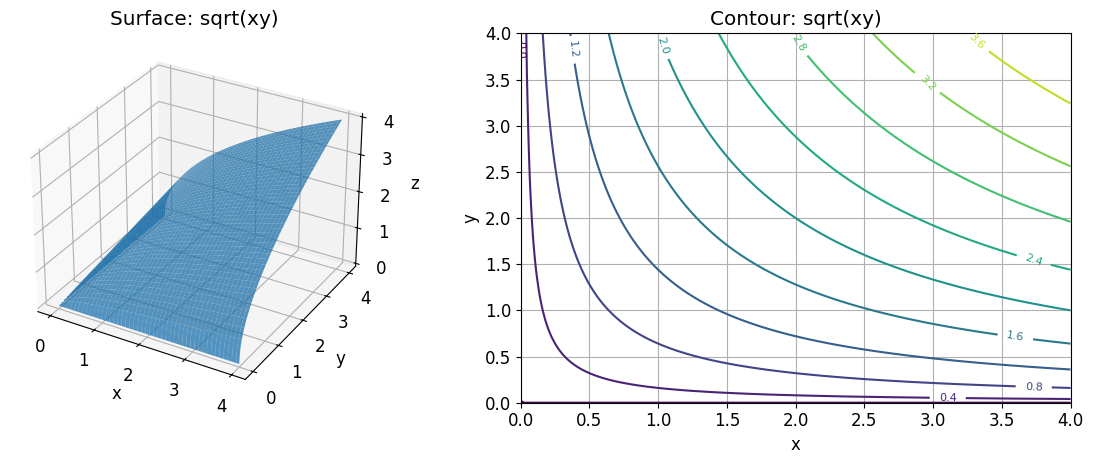

In [50]:
x = np.linspace(0.0, 4.0, 180)
y = np.linspace(0.0, 4.0, 180)
X, Y = np.meshgrid(x, y)
Z = np.sqrt(X * Y)

fig = plt.figure(figsize=(12, 4.8))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(X, Y, Z, alpha=0.75, linewidth=0.05)
ax1.set_title("Surface: sqrt(xy)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

ax2 = fig.add_subplot(122)
cs = ax2.contour(X, Y, Z, levels=10)
ax2.clabel(cs, inline=True, fontsize=8)
ax2.set_title("Contour: sqrt(xy)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

plt.tight_layout()
plt.show()


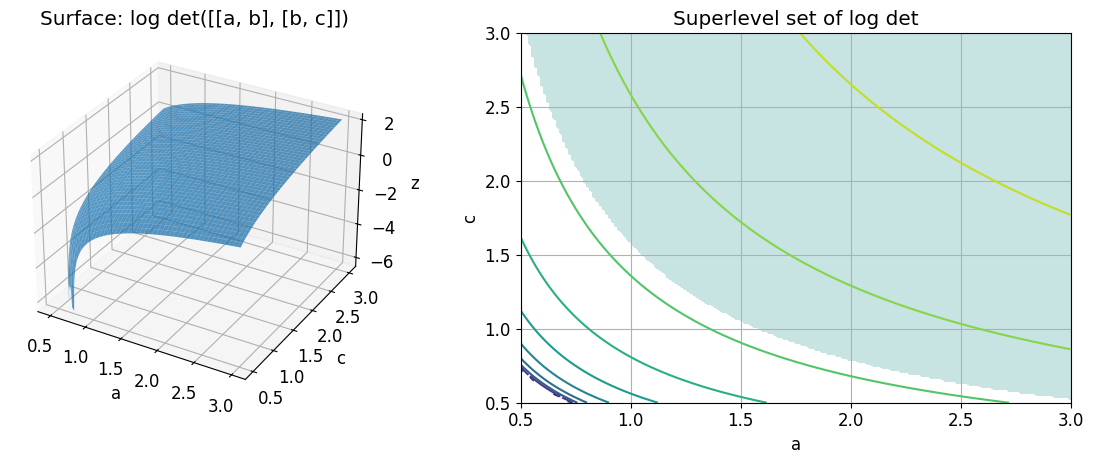

In [51]:
a_vals = np.linspace(0.5, 3.0, 180)
c_vals = np.linspace(0.5, 3.0, 180)
Agrid, Cgrid = np.meshgrid(a_vals, c_vals)
b = 0.6
det_vals = Agrid * Cgrid - b**2
Z = np.where(det_vals > 0, np.log(det_vals), np.nan)
alpha = 0.2

fig = plt.figure(figsize=(12, 4.8))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(Agrid, Cgrid, Z, alpha=0.75, linewidth=0.05)
ax1.set_title("Surface: log det([[a, b], [b, c]])")
ax1.set_xlabel("a")
ax1.set_ylabel("c")
ax1.set_zlabel("z")

ax2 = fig.add_subplot(122)
ax2.contour(Agrid, Cgrid, Z, levels=10)
ax2.contourf(Agrid, Cgrid, (Z >= alpha).astype(float), levels=[0.5, 1.5], alpha=0.25)
ax2.set_title("Superlevel set of log det")
ax2.set_xlabel("a")
ax2.set_ylabel("c")

plt.tight_layout()
plt.show()


### Part 6 생각해볼 질문

1. 왜 log-sum-exp는 $\max$의 매끄러운 근사라고 부를 수 있을까요?
2. 왜 geometric mean은 convex가 아니라 concave일까요?
3. 왜 log-det에서는 sublevel set보다 **superlevel set**이 더 자연스럽게 등장할까요?

### 짧은 해설
- log-sum-exp는 항상 $\max(x,y)$보다 크지만, 그 차이는 $\log 2$를 넘지 않습니다.
- geometric mean은 AM-GM 및 Hessian 계산을 통해 concavity를 확인할 수 있습니다.
- log-det는 concave이므로, convex한 쪽은 보통 sublevel set이 아니라 superlevel set입니다.


## Part 7. Optimization connection and synthesis 

 “그래서 이게 왜 최적화에서 중요한가?”

### 1. local minimum = global minimum (OT 시간에 언급한 내용 상기)
convex function $f$를 convex domain에서 최소화하면, local minimum이 있으면 그것이 곧 global minimum입니다.  
이 한 문장이 convex optimization의 엄청난 장점입니다.

### 2. first-order condition의 최적화 의미
미분 가능한 경우

$\nabla f(x^\star)=0$

이면 convexity 아래에서 그것은 전역 최소점입니다.  
nonsmooth한 경우에는

$0 \in \partial f(x^\star)$

가 대응되는 조건입니다.

### 3. 알고리즘 관점
convexity는 단지 정적인 기하가 아니라, gradient descent 같은 알고리즘이 “엉뚱한 지역해”에 갇힐 위험을 줄여줍니다.  
물론 수렴 속도는 curvature, condition number, step size의 영향을 받습니다.

아래 예시는 convex quadratic 위에서 gradient descent path가 어떻게 움직이는지 보여줍니다.


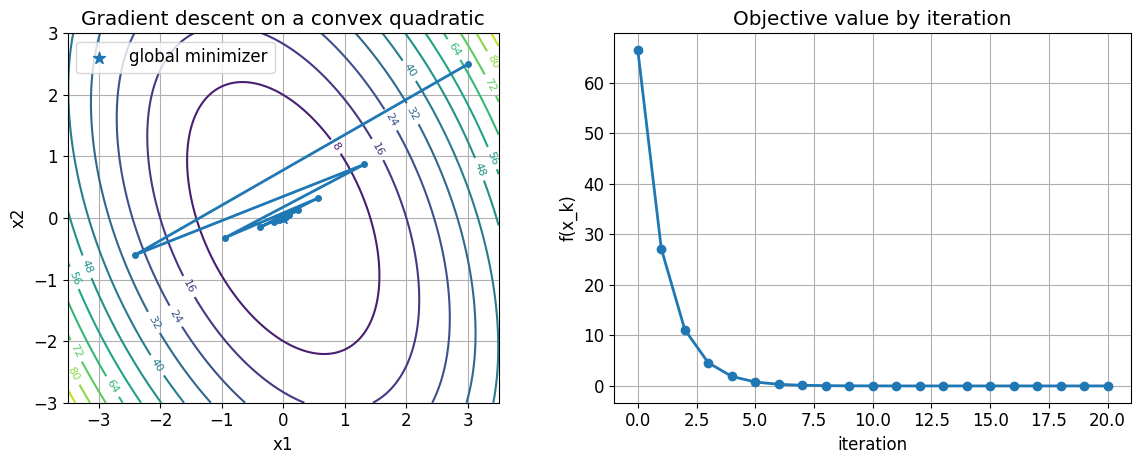

In [52]:
A = np.array([[4.0, 1.2], [1.2, 2.0]])
x0 = np.array([3.0, 2.5])
step = 0.18
path, values = gradient_descent_quadratic(A, x0, step, num_steps=20)

X, Y = make_grid((-3.5, 3.5), (-3.0, 3.0), n=300)
Z = quadratic_form(A, X, Y)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
cs = ax.contour(X, Y, Z, levels=12)
ax.clabel(cs, inline=True, fontsize=8)
ax.plot(path[:, 0], path[:, 1], "o-", linewidth=2, markersize=4)
ax.scatter([0], [0], s=80, marker="*", label="global minimizer")
ax.set_title("Gradient descent on a convex quadratic")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect("equal")
ax.legend()

ax = axes[1]
ax.plot(values, "o-", linewidth=2)
ax.set_title("Objective value by iteration")
ax.set_xlabel("iteration")
ax.set_ylabel("f(x_k)")

plt.tight_layout()
plt.show()


## 요약

### A. 집합 관점
- disk, ellipsoid, convex hull, halfspace는 왜 convex인가?
- supporting hyperplane은 무엇을 증명하는가?

### B. 함수 관점
- secant line inequality는 무엇을 뜻하는가?
- epigraph는 왜 함수 convexity와 동치인가?
- sublevel set과 contour line은 어떻게 다른가?

### C. 미분 관점
- first-order inequality는 왜 접선/접평면 underestimator인가?
- Hessian PSD는 왜 모든 방향 곡률의 비음수성을 뜻하는가?
- nonsmooth convexity는 왜 subgradient로 다루는가?

### D. 반례 관점
- `exp(-x^T A x)`는 convex가 아니라 log-concave
- `log(1+x^2+y^2)`는 전역 convex가 아님

### E. 최적화 관점
- convex minimization에서는 local minimum = global minimum
- log-sum-exp, quadratic-over-linear, log-det, geometric mean은 최적화에서 반복적으로 등장

---

## 노트북을 다 보고, 다시 한번 생각해보세요.

1. 이 함수/집합의 **정의역**은 무엇인가?
2. 이 예시는 **convex / concave / log-concave / nonconvex** 중 무엇인가?
3. 가장 짧은 증명은 **정의 / epigraph / sublevel / first-order / Hessian** 중 무엇인가?
4. 그림이 말해주는 것은 무엇이고, **그림만으로는 말할 수 없는 것**은 무엇인가?
5. 이 예시가 **최적화에서 왜 중요한가**?

---

## Appendix. 자주 쓰는 proof strategy 요약표

| 상황 | 가장 먼저 시도할 도구 |
|---|---|
| 1변수 smooth 함수 | second derivative |
| 2변수 이상 smooth 함수 | Hessian PSD |
| 그래프 위 영역이 자연스러울 때 | epigraph |
| 등고선/feasible region이 자연스러울 때 | sublevel set |
| 접선/접평면 그림이 잘 보일 때 | first-order inequality |
| nonsmooth 예시 (`|x|`, norms) | subgradient / triangle inequality |
| `max`, `log-sum-exp`, norms | known convexity-preserving operations |
| `x^2 / y` 같은 비율형 함수 | perspective transform |
| 반례를 잡고 싶을 때 | line restriction test |

이 표는 원본 노트북을 독해할 때도, 새로운 convexity 문제를 풀 때도 매우 유용합니다.
